# Train Flood Severity Classification — MobileNetV3 Large Complete Fixed

Notebook này được viết lại từ cấu trúc train hiện tại, nhưng **chỉ tập trung vào MobileNetV3 Large**.

## Mục tiêu chỉnh sửa

- Giữ cấu trúc train hiện tại: mount Drive → config → extract dataset → clean/split → dataloader → build model → train → evaluate → confusion matrix → misclassified → inference.
- Cố định model là **MobileNetV3 Large pretrained ImageNet**.
- Bổ sung các phần còn thiếu sau khi relabel:
  - Kiểm tra duplicate/cross-label duplicate.
  - Lưu `train/val/test split` để tránh lệch evaluation.
  - Early stopping theo validation accuracy, dùng critical error rate để phân xử trong biên 0.5%.
  - Hỗ trợ severity-aware loss với `λ=0.1`; đặt `λ=0.0` để chạy baseline CrossEntropy.
  - Class weight là tùy chọn; baseline accuracy mặc định không dùng trọng số lớp.
  - Differential learning rate: backbone LR nhỏ, classifier head LR lớn hơn.
  - Lưu checkpoint đầy đủ metadata: `class_order`, transform, config, split.
  - Xuất `classification_report`, confusion matrix raw/normalized.
  - Xuất ảnh validation đoán sai theo từng cặp lỗi để tiếp tục relabel; giữ test độc lập.
  - Fix cảnh báo AMP mới: dùng `torch.amp.autocast` và `torch.amp.GradScaler`.

## Class cố định

- `low`
- `medium`
- `high`
- `non_flood`

## Guideline relabel

| Class | Tiêu chí |
|---|---|
| `non_flood` | Không có nước ngập rõ ràng; đường khô/ướt/mưa/vũng nước nhỏ nhưng chưa phải ngập. |
| `low` | Có nước ngập rõ, nhưng dưới gối người; dưới thân thấp xe máy; dưới phần chính của bánh xe ô tô. |
| `medium` | Nước khoảng từ gối đến dưới ngực; tới/yên xe máy hoặc gần yên; qua bánh xe ô tô. |
| `high` | Nước từ ngực trở lên; qua tay lái xe máy; tới cửa kính/mái xe; ngập sâu vào nhà/cửa sổ. |

## Bản cập nhật trong file này

- Đặt `NUM_WORKERS = 0` mặc định để tránh lỗi `_MultiProcessingDataLoaderIter.__del__` trên Colab/notebook.
- Thêm hàm `make_loader()` để cấu hình `persistent_workers` và `prefetch_factor` chỉ khi `NUM_WORKERS > 0`.
- Dùng `pin_memory` chỉ khi có CUDA.
- Dùng `torch.amp.autocast(device_type=device.type, ...)` để tương thích hơn.
- Giữ checkpoint tốt nhất theo validation accuracy, lưu `last checkpoint`, history, confusion matrix và danh sách ảnh đoán sai trên validation.

## Update solution 17/06

File này đã được chỉnh theo hướng giảm overfitting và giữ lại mốc tham chiếu độ sâu nước:

- `BACKBONE_LR = 1e-5`, `HEAD_LR = 2e-4` để kiểm tra riêng tác động của learning rate backbone.
- `DROPOUT = 0.25` để giảm regularization nhưng vẫn hạn chế overfitting.
- Perceptual audit bằng dHash; ảnh gần giống được buộc ở cùng group, group xung đột nhãn bị loại để review.
- Split train/val/test theo source/perceptual group để ngăn data leakage.
- Train/val/test/inference dùng chung letterbox 256×256, không crop và không kéo giãn ảnh.
- Mọi artifact ghi vào `mobilenetv3_large`; báo cáo cuối chỉ dùng test split độc lập.



In [1]:
# Colab cần mount Drive để đọc Dataset_Flood_v4.zip; local bỏ qua cell này.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Local mode: không mount Google Drive.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import thư viện

In [2]:
import os
import json
import random
import shutil
import zipfile
import hashlib
import re
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

## 2. Cấu hình

In [3]:
# =========================
# CONFIG — MOBILENETV3 LARGE ONLY
# =========================
SEED = 599

# Mapping cố định. Không đổi thứ tự này nếu app inference đang dùng checkpoint theo thứ tự này.
CLASS_ORDER = ["low", "medium", "high", "non_flood"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_ORDER)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
SEVERITY_RANK = {"non_flood": 0, "low": 1, "medium": 2, "high": 3}

# Các folder review/không chắc chắn sẽ bị bỏ qua nếu có trong dataset.
IGNORE_DIR_NAMES = {
    "uncertain", "need_review", "review", "unknown", "ambiguous",
    "ignore", "ignored", "trash", "_trash", "duplicates", "conflict",
    "misclassified", "wrong", "_review",
}

# Colab dùng đúng Dataset_Flood_v4.zip; local tiếp tục dùng folder Dataset_Flood.
IS_COLAB = Path("/content/drive/MyDrive").is_dir()
if IS_COLAB:
    DATASET_DIR_CANDIDATES = []
    ZIP_PATH_CANDIDATES = [
        "/content/drive/MyDrive/Colab Notebooks/NCKH/Dataset_Flood_v4.zip",
    ]
    EXTRACT_DIR = "/content/flood_dataset_v4"
else:
    DATASET_DIR_CANDIDATES = [
        str(Path.cwd() / "Dataset_Flood"),
        str(Path.cwd() / "model" / "Dataset_Flood"),
        str(Path.cwd() / "fe" / "model" / "Dataset_Flood"),
        str(Path.cwd() / "nckh2" / "fe" / "model" / "Dataset_Flood"),
    ]
    ZIP_PATH_CANDIDATES = []
    EXTRACT_DIR = str(Path.cwd() / "flood_dataset_v4")

print("Dataset mode:", "Colab zip v4" if IS_COLAB else "Local Dataset_Flood")

# Mỗi seed có output riêng; mọi seed dùng chung split manifest.
BASE_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/NCKH/models" if os.path.exists("/content/drive") else "./models"
MODEL_VERSION = "mobilenetv3_large"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, f"mobilenetv3_large_dataset_v4_seed{SEED}")
SPLIT_CSV_PATH = os.path.join(BASE_OUTPUT_DIR, "mobilenetv3_large_dataset_v4", "split_train_val_test_mobilenetv3_large.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(SPLIT_CSV_PATH), exist_ok=True)

def remove_artifact_if_exists(path):
    """Xóa artifact cũ khi lần chạy hiện tại không có dữ liệu tương ứng."""
    path = Path(path)
    if path.is_dir():
        shutil.rmtree(path)
        return True
    if path.exists():
        path.unlink()
        return True
    return False


def save_nonempty_csv(df, path, *, index=False):
    """Chỉ lưu CSV có ít nhất một dòng; dọn file rỗng còn từ lần chạy trước."""
    if df is None or df.empty:
        removed = remove_artifact_if_exists(path)
        action = "Removed stale" if removed else "Skipped empty"
        print(f"{action}: {path}")
        return False

    df.to_csv(path, index=index)
    print("Saved:", path)
    return True

# Model — cố định MobileNetV3 Large.
MODEL_NAME = "mobilenetv3_large"
PRETRAINED = True
IMAGE_SIZE = 256
LETTERBOX_FILL = (124, 116, 104)
DROPOUT = 0.25

# Training.
BATCH_SIZE = 32
NUM_EPOCHS = 35
BACKBONE_LR = 1e-5      # Fine-tune backbone với learning rate của lần thử mới.
HEAD_LR = 2e-4          # Giữ tốc độ học của head như run lambda=0.1 trước đó.
WEIGHT_DECAY = 5e-4     # tăng nhẹ để giảm overfit.
LABEL_SMOOTHING = 0.05
SEVERITY_LOSS_WEIGHT = 0.1  # 0.0 = baseline CrossEntropy thuần.
CRITICAL_DISTANCE = 2
ACCURACY_TIE_TOLERANCE = 0.005
PATIENCE = 7
FREEZE_BACKBONE_EPOCHS = 3
NUM_WORKERS = 0  # Colab-safe. Nếu muốn tăng tốc, thử 2 sau khi train ổn định.
USE_AMP = True

# Split.
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Duplicate handling.
DEDUP_EXACT = True
PERCEPTUAL_HASH_DISTANCE = 3
PERCEPTUAL_MEAN_L1 = 30
EXCLUDE_CONFLICT_DUPLICATES = True

# Imbalance handling.
# Không bật đồng thời sampler và class_weight nếu không thật sự hiểu tác động.
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHT_LOSS = False

# Class weight nhẹ theo sqrt inverse frequency.
# Mục tiêu: hỗ trợ class ít như high nhưng không ép quá mạnh gây medium -> high.
CLASS_WEIGHT_POWER = 0.5
MIN_CLASS_WEIGHT = 0.70
MAX_CLASS_WEIGHT = 2.00
EXTRA_CLASS_MULTIPLIER = {
    "low": 1.00,
    "medium": 1.00,
    "high": 1.15,
    "non_flood": 1.00,
}

# Metric chọn checkpoint tốt nhất.
# Với dataset lệch class, macro_f1 hoặc balanced_acc tốt hơn accuracy.
BEST_METRIC = "acc"  # Ưu tiên độ chính xác tổng thể theo yêu cầu hiện tại.

SAVE_NAME = f"flood_{MODEL_NAME}_best.pth"
BEST_CKPT_PATH = os.path.join(OUTPUT_DIR, SAVE_NAME)
LAST_CKPT_PATH = os.path.join(OUTPUT_DIR, f"flood_{MODEL_NAME}_last.pth")

HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, "history_mobilenetv3_large.csv")
CONFIG_JSON_PATH = os.path.join(OUTPUT_DIR, "config_mobilenetv3_large.json")

CONFIG = {
    "model_version": MODEL_VERSION,
    "seed": SEED,
    "class_order": CLASS_ORDER,
    "model_name": MODEL_NAME,
    "pretrained": PRETRAINED,
    "image_size": IMAGE_SIZE,
    "preprocess": "letterbox",
    "letterbox_fill": LETTERBOX_FILL,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "severity_loss_weight": SEVERITY_LOSS_WEIGHT,
    "critical_distance": CRITICAL_DISTANCE,
    "accuracy_tie_tolerance": ACCURACY_TIE_TOLERANCE,
    "patience": PATIENCE,
    "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
    "num_workers": NUM_WORKERS,
    "use_amp": USE_AMP,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "perceptual_hash_distance": PERCEPTUAL_HASH_DISTANCE,
    "perceptual_mean_l1": PERCEPTUAL_MEAN_L1,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "use_class_weight_loss": USE_CLASS_WEIGHT_LOSS,
    "class_weight_power": CLASS_WEIGHT_POWER,
    "extra_class_multiplier": EXTRA_CLASS_MULTIPLIER,
    "best_metric": BEST_METRIC,
}

with open(CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, ensure_ascii=False, indent=2)

print("CLASS_TO_IDX:", CLASS_TO_IDX)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BEST_CKPT_PATH:", BEST_CKPT_PATH)
print("CONFIG_JSON_PATH:", CONFIG_JSON_PATH)

Dataset mode: Colab zip v4
CLASS_TO_IDX: {'low': 0, 'medium': 1, 'high': 2, 'non_flood': 3}
OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599
BEST_CKPT_PATH: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_best.pth
CONFIG_JSON_PATH: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/config_mobilenetv3_large.json


In [4]:
import logging
import sys

LOG_PATH = os.path.join(OUTPUT_DIR, "training.log")

logger = logging.getLogger("flood_training")
logger.setLevel(logging.INFO)
logger.propagate = False

if not logger.handlers:
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    file_handler = logging.FileHandler(LOG_PATH, encoding="utf-8")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

logger.info("Logger initialized")
logger.info("Output directory: %s", OUTPUT_DIR)
logger.info("Log file: %s", LOG_PATH)

2026-09-29 08:07:31 | INFO | Logger initialized
2026-09-29 08:07:31 | INFO | Output directory: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599
2026-09-29 08:07:31 | INFO | Log file: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/training.log


In [5]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # benchmark=True nhanh hơn cho image size cố định.
    # deterministic=False chấp nhận sai khác rất nhỏ giữa các lần chạy để tăng tốc.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if USE_WEIGHTED_SAMPLER and USE_CLASS_WEIGHT_LOSS:
    raise ValueError("Không nên bật đồng thời USE_WEIGHTED_SAMPLER và USE_CLASS_WEIGHT_LOSS.")

if BEST_METRIC not in {"acc", "macro_f1", "balanced_acc"}:
    raise ValueError("BEST_METRIC phải là 'acc', 'macro_f1' hoặc 'balanced_acc'.")

Device: cuda


## 3. Nạp dataset folder hoặc giải nén zip

Có thể đặt `source_groups.csv` ở thư mục gốc dataset để giữ ảnh cùng video/sự kiện trong một split. File gồm hai cột:

```csv
relative_path,source_group
low/frame_001.jpg,event_001
medium/frame_002.jpg,event_001
```

Nếu không có manifest này, notebook vẫn chống leakage bằng exact/perceptual duplicate.

In [6]:
def find_existing_zip(candidates):
    return next((p for p in candidates if Path(p).is_file()), None)

def find_existing_dataset_dir(candidates, expected_classes):
    expected = set(expected_classes)
    for candidate in candidates:
        path = Path(candidate)
        if path.is_dir() and expected.issubset({p.name for p in path.iterdir() if p.is_dir()}):
            return str(path)
    return None

dataset_dir = find_existing_dataset_dir(DATASET_DIR_CANDIDATES, CLASS_ORDER)
if dataset_dir is not None:
    EXTRACT_DIR = dataset_dir
    print("Using dataset folder:", EXTRACT_DIR)
else:
    zip_path = find_existing_zip(ZIP_PATH_CANDIDATES)
    if zip_path is None:
        raise FileNotFoundError(
            "Không tìm thấy Dataset_Flood_v4.zip trên Colab hoặc folder Dataset_Flood ở local."
        )

    print("Using zip:", zip_path)
    if os.path.exists(EXTRACT_DIR):
        shutil.rmtree(EXTRACT_DIR)
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)

    print("Extracted to:", EXTRACT_DIR)

Using zip: /content/drive/MyDrive/Colab Notebooks/NCKH/Dataset_Flood_v4.zip
Extracted to: /content/flood_dataset_v4


In [7]:
def find_dataset_root(base_dir, expected_classes):
    expected = set(expected_classes)
    for root, dirs, files in os.walk(base_dir):
        dir_set = set(dirs)
        if expected.issubset(dir_set):
            return root
    return None

DATA_DIR = find_dataset_root(EXTRACT_DIR, CLASS_ORDER)
if DATA_DIR is None:
    raise FileNotFoundError(
        f"Không tìm thấy folder chứa đủ các class {CLASS_ORDER} trong {EXTRACT_DIR}.\n"
        "Cấu trúc đúng nên là: Dataset/low, Dataset/medium, Dataset/high, Dataset/non_flood"
    )

print("DATA_DIR:", DATA_DIR)
print("Subfolders:", sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()]))

# Cảnh báo nếu có folder không nằm trong CLASS_ORDER hoặc IGNORE_DIR_NAMES.
extra_dirs = []
for p in Path(DATA_DIR).iterdir():
    if p.is_dir() and p.name not in CLASS_ORDER and p.name not in IGNORE_DIR_NAMES:
        extra_dirs.append(p.name)
if extra_dirs:
    print("Warning — folder không thuộc class/ignore:", extra_dirs)

DATA_DIR: /content/flood_dataset_v4/Dataset_Flood
Subfolders: ['high', 'low', 'medium', 'non_flood']


## 4. Kiểm tra dataset: class count, ảnh lỗi, duplicate

In [8]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".avif"}

def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.load()
        return True, ""
    except Exception as e:
        return False, repr(e)


def load_source_group_map(data_dir):
    """Đọc source_groups.csv với hai cột relative_path, source_group nếu có."""
    manifest_path = Path(data_dir) / "source_groups.csv"
    if not manifest_path.is_file():
        print("Không có source_groups.csv; split vẫn bảo vệ bằng perceptual group.")
        return {}

    manifest = pd.read_csv(manifest_path, dtype=str).fillna("")
    required = {"relative_path", "source_group"}
    if not required.issubset(manifest.columns):
        raise ValueError("source_groups.csv phải có cột relative_path và source_group.")
    manifest["relative_path"] = manifest["relative_path"].str.replace("\\", "/", regex=False)
    if manifest["relative_path"].duplicated().any():
        raise ValueError("source_groups.csv có relative_path bị trùng.")
    if (manifest["source_group"].str.strip() == "").any():
        raise ValueError("source_groups.csv không được để trống source_group.")
    print("Loaded source groups:", manifest_path, "rows=", len(manifest))
    return dict(zip(manifest["relative_path"], manifest["source_group"]))


def collect_image_records(data_dir, class_order):
    rows = []
    invalid_rows = []

    data_dir = Path(data_dir)
    source_group_map = load_source_group_map(data_dir)
    for label in class_order:
        class_dir = data_dir / label
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")

        for p in class_dir.rglob("*"):
            if p.is_dir():
                continue

            # Bỏ qua file trong folder review/ignore nếu người dùng vô tình đặt bên trong class.
            parts_lower = {part.lower() for part in p.parts}
            if any(name.lower() in parts_lower for name in IGNORE_DIR_NAMES):
                continue

            if p.suffix.lower() not in VALID_EXTS:
                continue

            ok, err = is_valid_image(str(p))
            if not ok:
                invalid_rows.append({
                    "path": str(p),
                    "label": label,
                    "error": err,
                })
                continue

            relative_path = p.relative_to(data_dir).as_posix()
            file_md5 = md5_file(str(p))
            rows.append({
                "path": str(p),
                "relative_path": relative_path,
                "label": label,
                "label_idx": CLASS_TO_IDX[label],
                "file_name": p.name,
                "md5": file_md5,
                "source_group": source_group_map.get(relative_path, ""),
            })

    records_df = pd.DataFrame(rows)
    invalid_df = pd.DataFrame(invalid_rows)
    return records_df, invalid_df


records_df, invalid_df = collect_image_records(DATA_DIR, CLASS_ORDER)

print("Valid image count:", len(records_df))
print("Invalid image count:", len(invalid_df))
print("\nClass counts before clean:")
print(records_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))

records_path = os.path.join(OUTPUT_DIR, "records_before_clean_mobilenetv3_large.csv")
invalid_path = os.path.join(OUTPUT_DIR, "invalid_images_mobilenetv3_large.csv")
records_df.to_csv(records_path, index=False)
save_nonempty_csv(invalid_df, invalid_path, index=False)

print("\nSaved:", records_path)

if len(invalid_df) > 0:
    display(invalid_df.head(20))

Không có source_groups.csv; split vẫn bảo vệ bằng perceptual group.
Valid image count: 1702
Invalid image count: 0

Class counts before clean:
label
low          377
medium       399
high         352
non_flood    574
Name: count, dtype: int64
Skipped empty: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/invalid_images_mobilenetv3_large.csv

Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/records_before_clean_mobilenetv3_large.csv


In [9]:
def build_clean_records(records_df):
    conflict_rows = []
    same_label_dup_rows = []
    keep_indices = []

    for md5, group in records_df.groupby("md5"):
        labels = sorted(group["label"].unique().tolist())

        if len(labels) > 1:
            # Một ảnh xuất hiện ở nhiều class khác nhau -> nguy hiểm, bỏ khỏi train.
            for _, row in group.iterrows():
                conflict_rows.append({
                    "md5": md5,
                    "path": row["path"],
                    "label": row["label"],
                    "conflict_labels": ",".join(labels),
                })
            if not EXCLUDE_CONFLICT_DUPLICATES:
                keep_indices.extend(group.index.tolist())
            continue

        # Trùng y hệt trong cùng class -> giữ 1 ảnh nếu DEDUP_EXACT=True.
        if len(group) > 1:
            sorted_group = group.sort_values("path")
            keep_idx = sorted_group.index[0]
            for dup_idx in sorted_group.index[1:]:
                same_label_dup_rows.append({
                    "md5": md5,
                    "kept_path": records_df.loc[keep_idx, "path"],
                    "duplicate_path": records_df.loc[dup_idx, "path"],
                    "label": records_df.loc[dup_idx, "label"],
                })
            if DEDUP_EXACT:
                keep_indices.append(keep_idx)
            else:
                keep_indices.extend(group.index.tolist())
        else:
            keep_indices.extend(group.index.tolist())

    clean_df = records_df.loc[sorted(set(keep_indices))].reset_index(drop=True).copy()
    conflict_df = pd.DataFrame(conflict_rows)
    same_label_dup_df = pd.DataFrame(same_label_dup_rows)
    return clean_df, conflict_df, same_label_dup_df


clean_df, conflict_df, same_label_dup_df = build_clean_records(records_df)


def perceptual_signature(path):
    """dHash 64-bit + mean RGB để audit ảnh gần giống mà không thêm dependency."""
    with Image.open(path) as img:
        rgb = ImageOps.exif_transpose(img).convert("RGB")
        gray = rgb.convert("L").resize((9, 8), Image.Resampling.LANCZOS)
        pixels = np.asarray(gray, dtype=np.int16)
        bits = pixels[:, 1:] > pixels[:, :-1]
        dhash = 0
        for bit in bits.reshape(-1):
            dhash = (dhash << 1) | int(bit)
        mean_rgb = np.asarray(rgb.resize((1, 1), Image.Resampling.BOX))[0, 0].astype(np.int16)
    return dhash, mean_rgb


def add_perceptual_groups(df):
    """Gom ảnh gần giống vào cùng group; group khác nhãn bị loại để review."""
    result = df.reset_index(drop=True).copy()
    signatures = [perceptual_signature(path) for path in tqdm(result["path"], desc="Perceptual audit")]
    hashes = [item[0] for item in signatures]
    means = np.stack([item[1] for item in signatures])
    parent = list(range(len(result)))

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    for left in tqdm(range(len(result)), desc="Grouping near-duplicates"):
        for right in range(left + 1, len(result)):
            if (hashes[left] ^ hashes[right]).bit_count() > PERCEPTUAL_HASH_DISTANCE:
                continue
            if int(np.abs(means[left] - means[right]).sum()) <= PERCEPTUAL_MEAN_L1:
                union(left, right)

    members = defaultdict(list)
    for index in range(len(result)):
        members[find(index)].append(index)

    group_ids = {}
    for root, indices in members.items():
        stable_key = "|".join(sorted(result.loc[indices, "md5"].tolist()))
        group_ids[root] = "ph_" + hashlib.sha1(stable_key.encode("utf-8")).hexdigest()[:16]

    result["dhash"] = [f"{value:016x}" for value in hashes]
    result["perceptual_group"] = [group_ids[find(index)] for index in range(len(result))]
    group_label_count = result.groupby("perceptual_group")["label"].transform("nunique")
    conflict_rows = result[group_label_count > 1].copy()
    if EXCLUDE_CONFLICT_DUPLICATES:
        result = result[group_label_count == 1].copy()

    group_sizes = result.groupby("perceptual_group")["path"].transform("size")
    audit_rows = result[group_sizes > 1].copy()
    audit_rows["group_size"] = group_sizes[group_sizes > 1].astype(int)
    return result.reset_index(drop=True), audit_rows, conflict_rows


def add_split_groups(df):
    """Hợp nhất near-duplicate và cùng nguồn để không rơi vào nhiều split."""
    result = df.reset_index(drop=True).copy()
    parent = list(range(len(result)))

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    for column in ("perceptual_group", "source_group"):
        grouped = result[result[column].astype(str).str.len() > 0].groupby(column).groups
        for indices in grouped.values():
            indices = list(indices)
            for index in indices[1:]:
                union(indices[0], index)

    members = defaultdict(list)
    for index in range(len(result)):
        members[find(index)].append(index)

    group_ids = {}
    for root, indices in members.items():
        stable_key = "|".join(sorted(result.loc[indices, "md5"].tolist()))
        group_ids[root] = "split_" + hashlib.sha1(stable_key.encode("utf-8")).hexdigest()[:16]
    result["split_group"] = [group_ids[find(index)] for index in range(len(result))]
    return result


clean_df, perceptual_audit_df, perceptual_conflict_df = add_perceptual_groups(clean_df)
clean_df = add_split_groups(clean_df)

conflict_path = os.path.join(OUTPUT_DIR, "duplicate_conflicts_cross_label_mobilenetv3_large.csv")
same_dup_path = os.path.join(OUTPUT_DIR, "duplicate_same_label_mobilenetv3_large.csv")
perceptual_audit_path = os.path.join(OUTPUT_DIR, "perceptual_near_duplicates_mobilenetv3_large.csv")
perceptual_conflict_path = os.path.join(OUTPUT_DIR, "perceptual_conflicts_cross_label_mobilenetv3_large.csv")
clean_path = os.path.join(OUTPUT_DIR, "records_after_clean_mobilenetv3_large.csv")

save_nonempty_csv(conflict_df, conflict_path, index=False)
save_nonempty_csv(same_label_dup_df, same_dup_path, index=False)
save_nonempty_csv(perceptual_audit_df, perceptual_audit_path, index=False)
save_nonempty_csv(perceptual_conflict_df, perceptual_conflict_path, index=False)
clean_df.to_csv(clean_path, index=False)

print("After clean:", len(clean_df))
print("\nClass counts after clean:")
print(clean_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))

print("\nCross-label duplicate conflicts:", len(conflict_df))
print("Same-label exact duplicates:", len(same_label_dup_df))
print("Perceptual near-duplicate rows kept in groups:", len(perceptual_audit_df))
print("Perceptual cross-label conflict rows excluded:", len(perceptual_conflict_df))

print("\nSaved:", clean_path)

if len(conflict_df) > 0:
    print("\nCẦN RÀ SOÁT: Một số ảnh trùng nhưng khác nhãn:")
    display(conflict_df.head(20))

Perceptual audit:   0%|          | 0/1702 [00:00<?, ?it/s]

Grouping near-duplicates:   0%|          | 0/1702 [00:00<?, ?it/s]

Skipped empty: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/duplicate_conflicts_cross_label_mobilenetv3_large.csv
Skipped empty: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/duplicate_same_label_mobilenetv3_large.csv
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/perceptual_near_duplicates_mobilenetv3_large.csv
Skipped empty: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/perceptual_conflicts_cross_label_mobilenetv3_large.csv
After clean: 1702

Class counts after clean:
label
low          377
medium       399
high         352
non_flood    574
Name: count, dtype: int64

Cross-label duplicate conflicts: 0
Same-label exact duplicates: 0
Perceptual near-duplicate rows kept in groups: 49
Perceptual cross-label conflict rows excluded: 0

Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset

## 5. Stratified split train/val/test

In [10]:
# Kiểm tra số lượng tối thiểu mỗi class.
counts = clean_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
print(counts)
group_counts = (clean_df.drop_duplicates("split_group")["label"]
                .value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))
print("Perceptual groups per class:")
print(group_counts)

if (group_counts < 3).any():
    raise ValueError(
        "Có class dưới 3 split groups, không đủ để grouped train/val/test. "
        "Hãy bổ sung dữ liệu hoặc giảm số split."
    )

total_groups = int(clean_df["split_group"].nunique())
test_group_count = int(np.ceil(total_groups * TEST_SIZE))
train_val_group_count = total_groups - test_group_count
val_group_count = int(np.ceil(train_val_group_count * (VAL_SIZE / (1.0 - TEST_SIZE))))
if min(test_group_count, val_group_count) < len(CLASS_ORDER):
    raise ValueError(
        "Số split groups quá ít để stratify đủ bốn class trong validation/test."
    )


def try_load_existing_split(clean_df, split_csv_path):
    """Nạp lại split cũ nếu file split đã tồn tại.

    Chỉ tạo split khi chưa có manifest. Nếu manifest đã tồn tại nhưng không khớp,
    dừng để tránh âm thầm đổi test set giữa các seed.

    Ưu tiên match bằng md5 để đổi nhãn không làm ảnh chuyển sang split khác.
    Nếu manifest hiện hữu không khớp dataset, dừng để tránh đổi held-out âm thầm.
    """
    if not os.path.exists(split_csv_path):
        return None

    old_split_df = pd.read_csv(split_csv_path)
    if "split" not in old_split_df.columns:
        raise ValueError("Split manifest tồn tại nhưng thiếu cột 'split'; không tự tạo split mới.")

    if "md5" in clean_df.columns and "md5" in old_split_df.columns:
        key_cols = ["md5"]
    elif "relative_path" in clean_df.columns and "relative_path" in old_split_df.columns:
        key_cols = ["relative_path"]
    else:
        raise ValueError("Split manifest không có khóa md5/relative_path; cần kiểm tra thủ công.")

    current_keys = set(map(tuple, clean_df[key_cols].astype(str).values.tolist()))
    old_keys = set(map(tuple, old_split_df[key_cols].astype(str).values.tolist()))

    if current_keys != old_keys:
        missing_in_old = len(current_keys - old_keys)
        missing_in_current = len(old_keys - current_keys)
        raise ValueError(
            "Dataset không khớp split manifest; dừng để giữ nguyên held-out. "
            f"missing_in_old={missing_in_old}, missing_in_current={missing_in_current}. "
            "Nếu chủ ý đổi dataset, hãy tạo manifest phiên bản mới có chủ đích."
        )

    if old_split_df.duplicated(key_cols).any():
        raise ValueError("Split manifest có khóa ảnh trùng; cần kiểm tra thủ công.")

    split_map = {
        tuple(row[key_cols].astype(str).tolist()): row["split"]
        for _, row in old_split_df.iterrows()
    }

    reused_df = clean_df.copy()
    reused_df["split"] = [
        split_map[tuple(map(str, row))]
        for row in reused_df[key_cols].values.tolist()
    ]

    valid_splits = {"train", "val", "test"}
    found_splits = set(reused_df["split"].dropna().unique().tolist())
    if found_splits != valid_splits:
        raise ValueError(f"Split manifest không đủ train/val/test: {found_splits}.")

    leaked_groups = reused_df.groupby("split_group")["split"].nunique()
    if (leaked_groups > 1).any():
        raise ValueError("Split manifest làm source/perceptual group rò rỉ giữa các split.")

    print("Loaded existing split:", split_csv_path)
    print("Key used:", key_cols)
    return reused_df


clean_df_with_split = try_load_existing_split(clean_df, SPLIT_CSV_PATH)

if clean_df_with_split is None:
    group_df = (clean_df.groupby("split_group", as_index=False)
                .agg(label=("label", lambda values: values.mode().iloc[0]),
                     label_idx=("label_idx", lambda values: int(values.mode().iloc[0]))))
    groups = group_df["split_group"].values
    group_y = group_df["label_idx"].values

    train_val_groups, test_groups = train_test_split(
        groups,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=group_y,
    )

    group_label_map = group_df.set_index("split_group")["label_idx"]
    train_val_y = group_label_map.loc[train_val_groups].values
    relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)

    train_groups, val_groups = train_test_split(
        train_val_groups,
        test_size=relative_val_size,
        random_state=SEED,
        stratify=train_val_y,
    )

    split_map = {**{group: "train" for group in train_groups},
                 **{group: "val" for group in val_groups},
                 **{group: "test" for group in test_groups}}
    clean_df["split"] = clean_df["split_group"].map(split_map)
    print("Created new stratified grouped split with SEED:", SEED)
else:
    clean_df = clean_df_with_split

# Lưu/ghi lại split đang dùng để lần sau evaluate đúng cùng tập.
assert clean_df["split"].notna().all(), "Có ảnh chưa được gán split."
group_split_counts = clean_df.groupby("split_group")["split"].nunique()
assert int(group_split_counts.max()) == 1, "Data leakage: một source/perceptual group nằm ở nhiều split."
clean_df.to_csv(SPLIT_CSV_PATH, index=False)
print("Saved split:", SPLIT_CSV_PATH)

split_counts = pd.crosstab(clean_df["split"], clean_df["label"]).reindex(
    index=["train", "val", "test"],
    columns=CLASS_ORDER,
    fill_value=0,
)
display(split_counts)

split_ratio = split_counts.div(split_counts.sum(axis=1), axis=0).round(3)
display(split_ratio)


label
low          377
medium       399
high         352
non_flood    574
Name: count, dtype: int64
Perceptual groups per class:
label
low          375
medium       386
high         343
non_flood    573
Name: count, dtype: int64
Loaded existing split: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4/split_train_val_test_mobilenetv3_large.csv
Key used: ['md5']
Saved split: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4/split_train_val_test_mobilenetv3_large.csv


label,low,medium,high,non_flood
split,,,,
train,264,278,245,402
val,57,61,53,86
test,56,60,54,86


label,low,medium,high,non_flood
split,,,,
train,0.222,0.234,0.206,0.338
val,0.222,0.237,0.206,0.335
test,0.219,0.234,0.211,0.336


## 6. Dataset, transform và dataloader

> Train/val/test/inference đều giữ nguyên tỉ lệ ảnh và letterbox về 256×256. Không dùng `RandomResizedCrop`, `CenterCrop` hoặc kéo giãn ảnh. File này đặt `NUM_WORKERS = 0` mặc định để tránh lỗi multiprocessing trên Colab.

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class Letterbox:
    """Resize giữ tỉ lệ rồi pad đúng IMAGE_SIZE; giống web và Flutter."""
    def __init__(self, size, fill):
        self.size = (size, size)
        self.fill = tuple(fill)

    def __call__(self, image):
        return ImageOps.pad(
            image,
            self.size,
            method=Image.Resampling.BILINEAR,
            color=self.fill,
            centering=(0.5, 0.5),
        )


# Augmentation nhẹ, không crop mất mốc độ sâu.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=4, translate=(0.03, 0.03), scale=(0.95, 1.05), fill=LETTERBOX_FILL
    ),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class FloodDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.letterbox = Letterbox(IMAGE_SIZE, LETTERBOX_FILL)
        self.image_cache = {} if NUM_WORKERS == 0 else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label_idx"])

        try:
            if self.image_cache is not None and path in self.image_cache:
                img = self.image_cache[path].copy()
            else:
                with Image.open(path) as source:
                    img = self.letterbox(ImageOps.exif_transpose(source).convert("RGB"))
                if self.image_cache is not None:
                    self.image_cache[path] = img.copy()
        except Exception as e:
            raise RuntimeError(f"Không đọc được ảnh: {path} | {repr(e)}")

        if self.transform:
            img = self.transform(img)

        return img, label, path


train_df = clean_df[clean_df["split"] == "train"].reset_index(drop=True)
val_df = clean_df[clean_df["split"] == "val"].reset_index(drop=True)
test_df = clean_df[clean_df["split"] == "test"].reset_index(drop=True)

train_dataset = FloodDataset(train_df, transform=train_transform)
val_dataset = FloodDataset(val_df, transform=val_test_transform)
test_dataset = FloodDataset(test_df, transform=val_test_transform)

train_labels = train_df["label_idx"].values
train_counter = Counter(train_labels)

if USE_WEIGHTED_SAMPLER:
    class_sample_counts = np.array([train_counter[i] for i in range(len(CLASS_ORDER))], dtype=np.float32)
    sample_weights = np.array([1.0 / class_sample_counts[label] for label in train_labels], dtype=np.float32)
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

# Generator giúp shuffle ổn định hơn khi cần reproduce.
g = torch.Generator()
g.manual_seed(SEED)


def seed_worker(worker_id):
    """Seed cho mỗi DataLoader worker khi NUM_WORKERS > 0."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle=False, sampler=None, generator=None):
    """Tạo DataLoader an toàn cho Colab/notebook.

    Mặc định NUM_WORKERS = 0 để tránh lỗi multiprocessing:
    AssertionError: can only test a child process.

    Nếu dataset lớn và muốn tăng tốc, có thể thử NUM_WORKERS = 2.
    Khi đó mới bật persistent_workers và prefetch_factor.
    """
    kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
        "num_workers": NUM_WORKERS,
        "pin_memory": device.type == "cuda",
        "drop_last": False,
    }

    if generator is not None:
        kwargs["generator"] = generator

    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
        kwargs["worker_init_fn"] = seed_worker

    return DataLoader(**kwargs)


train_loader = make_loader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=sampler,
    generator=g,
)
val_loader = make_loader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Train class counts:", {CLASS_ORDER[k]: int(v) for k, v in sorted(train_counter.items())})
print("NUM_WORKERS:", NUM_WORKERS)
print("pin_memory:", device.type == "cuda")

Train/Val/Test: 1189 257 256
Train class counts: {'low': 264, 'medium': 278, 'high': 245, 'non_flood': 402}
NUM_WORKERS: 0
pin_memory: True


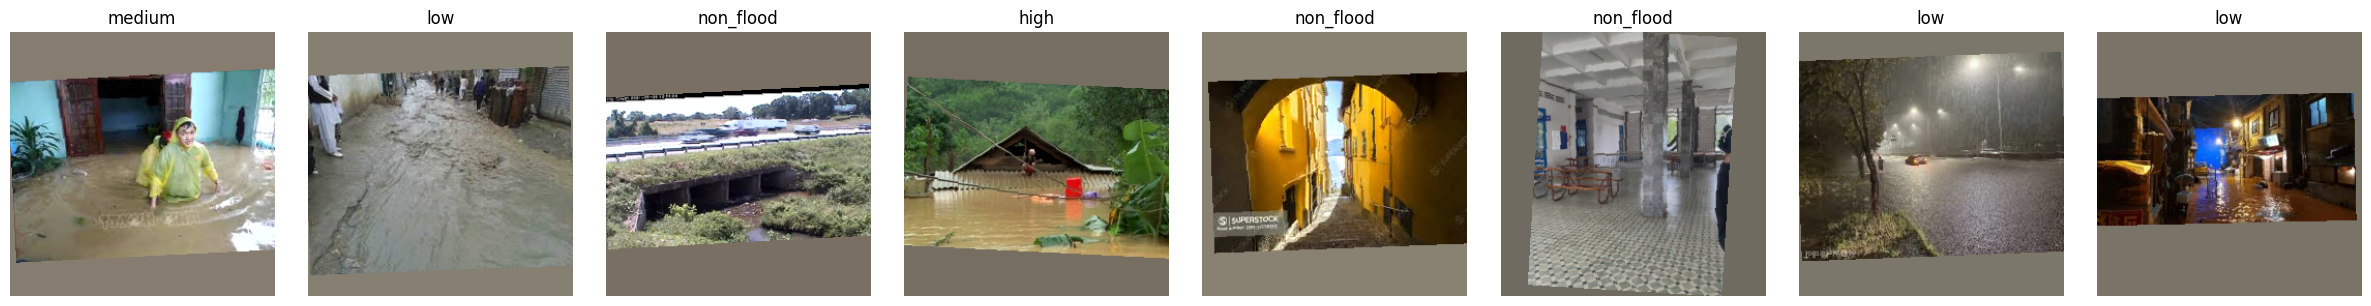

In [12]:
def show_batch(dataset, n=8):
    n = min(n, len(dataset))
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    sample_indices = np.random.choice(len(dataset), n, replace=False)
    for ax, idx in zip(axes, sample_indices):
        img_tensor, label, path = dataset[idx]
        img = img_tensor.permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(CLASS_ORDER[label])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=8)

## 7. Build model — MobileNetV3 Large only

In [13]:
def build_mobilenetv3_large(num_classes: int, dropout: float = 0.25, pretrained: bool = True):
    """Build MobileNetV3-Large pretrained ImageNet cho bài toán 4-class flood severity.

    Lưu ý:
    - Giữ toàn bộ backbone pretrained.
    - Chỉ thay lớp classifier cuối cùng để tránh lệch kiến trúc khi load checkpoint.
    - MobileNetV3 phù hợp khi cần model nhẹ, inference nhanh nhưng vẫn giữ chất lượng tốt cho image classification.
    """
    weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_large(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier[-2] = nn.Dropout(p=dropout)
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def set_backbone_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable


model = build_mobilenetv3_large(
    num_classes=len(CLASS_ORDER),
    dropout=DROPOUT,
    pretrained=PRETRAINED,
).to(device)
set_backbone_trainable(model, FREEZE_BACKBONE_EPOCHS == 0)

total_params, trainable_params = count_trainable_params(model)
print(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

## 8. Loss, optimizer, scheduler

Loss thử nghiệm dùng công thức `total_loss = cross_entropy + λ × severity_loss`, với thứ hạng `non_flood=0`, `low=1`, `medium=2`, `high=3`. `severity_loss` là kỳ vọng khoảng cách tuyệt đối giữa nhãn thật và phân phối dự đoán, nên xác suất đặt vào lớp càng xa càng bị phạt mạnh. Đặt `SEVERITY_LOSS_WEIGHT = 0.0` để chạy baseline CrossEntropy thuần; giá trị `0.1` bật thử nghiệm severity-aware.

Checkpoint vẫn ưu tiên validation accuracy. Khi accuracy nằm trong biên `0.5%` so với mức cao nhất, model có `critical_error_rate` thấp hơn được chọn.

In [14]:
def compute_class_weights_from_counts(train_counter, class_order):
    counts = np.array([train_counter[i] for i in range(len(class_order))], dtype=np.float32)
    if np.any(counts <= 0):
        raise ValueError("Có class không có ảnh trong train split.")

    # sqrt inverse frequency: nhẹ hơn inverse frequency thô.
    inv = (counts.sum() / (len(class_order) * counts)) ** CLASS_WEIGHT_POWER

    multipliers = np.array(
        [EXTRA_CLASS_MULTIPLIER.get(class_order[i], 1.0) for i in range(len(class_order))],
        dtype=np.float32,
    )
    weights = inv * multipliers

    # Normalize quanh mean=1 để loss ổn định hơn.
    weights = weights / weights.mean()
    weights = np.clip(weights, MIN_CLASS_WEIGHT, MAX_CLASS_WEIGHT)
    return weights


if USE_CLASS_WEIGHT_LOSS:
    class_weights = compute_class_weights_from_counts(train_counter, CLASS_ORDER)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print("Class weights:", {CLASS_ORDER[i]: float(class_weights[i]) for i in range(len(CLASS_ORDER))})
else:
    class_weights = None
    class_weights_tensor = None

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)
severity_rank_tensor = torch.tensor(
    [SEVERITY_RANK[name] for name in CLASS_ORDER], dtype=torch.float32, device=device
)


def compute_loss_components(logits, labels, criterion):
    """CE + kỳ vọng khoảng cách mức độ; lambda=0 trả về baseline CE."""
    ce_loss = criterion(logits, labels)
    probabilities = torch.softmax(logits, dim=1)
    true_ranks = severity_rank_tensor[labels]
    distances = (severity_rank_tensor.unsqueeze(0) - true_ranks.unsqueeze(1)).abs()
    severity_loss = (probabilities * distances).sum(dim=1).mean()
    total_loss = ce_loss + SEVERITY_LOSS_WEIGHT * severity_loss
    return total_loss, ce_loss, severity_loss


def build_optimizer(model):
    # Differential LR: backbone học chậm, classifier head học nhanh.
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if name.startswith("classifier."):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    return optimizer


optimizer = build_optimizer(model)

# ReduceLROnPlateau theo validation metric; các metric hỗ trợ đều càng cao càng tốt.
def build_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7
    )


scheduler = build_scheduler(optimizer)

# AMP mới cho PyTorch 2.x.
amp_enabled = bool(USE_AMP and device.type == "cuda")
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)

print("AMP enabled:", amp_enabled)
print("Optimizer param group LRs:", [group["lr"] for group in optimizer.param_groups])

AMP enabled: True
Optimizer param group LRs: [1e-05, 0.0002]


## 9. Train / evaluate functions

In [15]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    ranks = np.asarray([SEVERITY_RANK[name] for name in CLASS_ORDER], dtype=np.int64)
    severity_distances = np.abs(ranks[y_true] - ranks[y_pred])
    critical_error_count = int(np.sum(severity_distances >= CRITICAL_DISTANCE))
    return {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "critical_error_rate": float(np.mean(severity_distances >= CRITICAL_DISTANCE)),
        "critical_error_count": critical_error_count,
        "num_samples": int(len(y_true)),
        "mean_severity_distance": float(np.mean(severity_distances)),
    }


def compute_per_class_metrics(y_true, y_pred, class_order):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_order))),
        zero_division=0,
    )
    result = {}
    for i, cls in enumerate(class_order):
        result[f"{cls}_precision"] = float(precision[i])
        result[f"{cls}_recall"] = float(recall[i])
        result[f"{cls}_f1"] = float(f1[i])
        result[f"{cls}_support"] = int(support[i])
    return result


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, backbone_frozen=False):
    model.train()
    if backbone_frozen:
        model.features.eval()  # Không cập nhật BatchNorm khi backbone đang khóa.
    total_loss = 0.0
    total_ce_loss = 0.0
    total_severity_loss = 0.0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, labels, paths in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images)
            loss, ce_loss, severity_loss = compute_loss_components(logits, labels, criterion)

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer.step()

        total_loss += float(loss.item()) * images.size(0)
        total_ce_loss += float(ce_loss.item()) * images.size(0)
        total_severity_loss += float(severity_loss.item()) * images.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=float(loss.item()))

    metrics = compute_metrics(y_true, y_pred)
    metrics.update(compute_per_class_metrics(y_true, y_pred, CLASS_ORDER))
    metrics["loss"] = total_loss / len(loader.dataset)
    metrics["ce_loss"] = total_ce_loss / len(loader.dataset)
    metrics["severity_loss"] = total_severity_loss / len(loader.dataset)
    metrics["severity_penalty"] = SEVERITY_LOSS_WEIGHT * metrics["severity_loss"]
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_ce_loss = 0.0
    total_severity_loss = 0.0
    y_true, y_pred, y_prob, img_paths = [], [], [], []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images)
            loss, ce_loss, severity_loss = compute_loss_components(logits, labels, criterion)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        total_loss += float(loss.item()) * images.size(0)
        total_ce_loss += float(ce_loss.item()) * images.size(0)
        total_severity_loss += float(severity_loss.item()) * images.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        img_paths.extend(list(paths))

    metrics = compute_metrics(y_true, y_pred)
    metrics.update(compute_per_class_metrics(y_true, y_pred, CLASS_ORDER))
    metrics["loss"] = total_loss / len(loader.dataset)
    metrics["ce_loss"] = total_ce_loss / len(loader.dataset)
    metrics["severity_loss"] = total_severity_loss / len(loader.dataset)
    metrics["severity_penalty"] = SEVERITY_LOSS_WEIGHT * metrics["severity_loss"]

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob), img_paths

## 10. Training loop

In [16]:
history = []
best_score = -1.0
best_critical_error_rate = float("inf")
max_accuracy_seen = -1.0
best_epoch = -1
epochs_no_improve = 0

logger.info(
    "Training started | epochs=%d | batch_size=%d | device=%s | best_metric=%s | "
    "severity_lambda=%.3f | critical_distance=%d | accuracy_tie_tolerance=%.3f",
    NUM_EPOCHS,
    BATCH_SIZE,
    device,
    BEST_METRIC,
    SEVERITY_LOSS_WEIGHT,
    CRITICAL_DISTANCE,
    ACCURACY_TIE_TOLERANCE,
)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_started = datetime.now()
    logger.info("Epoch %d/%d started", epoch, NUM_EPOCHS)
    backbone_frozen = epoch <= FREEZE_BACKBONE_EPOCHS
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        set_backbone_trainable(model, True)
        scheduler = build_scheduler(optimizer)
        epochs_no_improve = 0
        logger.info("Backbone unfrozen at epoch %d", epoch)

    try:
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            scaler=scaler,
            backbone_frozen=backbone_frozen,
        )
        val_metrics, val_true, val_pred, val_prob, val_paths = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        current_score = val_metrics[BEST_METRIC]
        current_accuracy = val_metrics["acc"]
        current_critical_error_rate = val_metrics["critical_error_rate"]
        max_accuracy_seen = max(max_accuracy_seen, current_accuracy)
        scheduler.step(current_score)

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr_backbone": optimizer.param_groups[0]["lr"],
            "lr_head": optimizer.param_groups[1]["lr"],
        }
        history.append(row)

        logger.info(
            "Epoch %d/%d | train_total=%.4f train_ce=%.4f train_severity_penalty=%.4f train_acc=%.4f | "
            "val_total=%.4f val_ce=%.4f val_severity_penalty=%.4f val_acc=%.4f | "
            "val_critical=%d/%d (%.4f) val_mean_distance=%.4f",
            epoch,
            NUM_EPOCHS,
            train_metrics["loss"],
            train_metrics["ce_loss"],
            train_metrics["severity_penalty"],
            train_metrics["acc"],
            val_metrics["loss"],
            val_metrics["ce_loss"],
            val_metrics["severity_penalty"],
            val_metrics["acc"],
            val_metrics["critical_error_count"],
            val_metrics["num_samples"],
            val_metrics["critical_error_rate"],
            val_metrics["mean_severity_distance"],
        )
        logger.info(
            "Epoch %d/%d | validation recall=%s | lr_backbone=%.2e lr_head=%.2e | elapsed=%s",
            epoch,
            NUM_EPOCHS,
            {cls: round(val_metrics[f"{cls}_recall"], 3) for cls in CLASS_ORDER},
            optimizer.param_groups[0]["lr"],
            optimizer.param_groups[1]["lr"],
            datetime.now() - epoch_started,
        )

        accuracy_clearly_better = current_accuracy > best_score + ACCURACY_TIE_TOLERANCE
        accuracy_in_top_band = current_accuracy >= max_accuracy_seen - ACCURACY_TIE_TOLERANCE
        critical_rate_better = current_critical_error_rate < best_critical_error_rate - 1e-12
        is_best = (
            best_epoch < 0
            or accuracy_clearly_better
            or (accuracy_in_top_band and critical_rate_better)
        )
        selection_reason = (
            "higher_accuracy" if accuracy_clearly_better or best_epoch < 0
            else "lower_critical_error_within_accuracy_tolerance"
        )

        checkpoint = {
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_metric": BEST_METRIC,
            "best_score": float(current_accuracy if is_best else best_score),
            "best_critical_error_rate": float(
                current_critical_error_rate if is_best else best_critical_error_rate
            ),
            "selection_reason": selection_reason if is_best else "not_selected",
            "current_score": float(current_score),
            "validation_metrics": {
                key: float(value) if isinstance(value, (np.floating, float))
                else int(value) if isinstance(value, (np.integer, int)) else value
                for key, value in val_metrics.items()
            },
            "class_names": CLASS_ORDER,
            "class_order": CLASS_ORDER,
            "class_to_idx": CLASS_TO_IDX,
            "idx_to_class": IDX_TO_CLASS,
            "model_version": MODEL_VERSION,
            "image_size": IMAGE_SIZE,
            "preprocess": "letterbox",
            "letterbox_fill": LETTERBOX_FILL,
            "dropout": DROPOUT,
            "pretrained": PRETRAINED,
            "imagenet_mean": IMAGENET_MEAN,
            "imagenet_std": IMAGENET_STD,
            "config": CONFIG,
            "class_weights": None if class_weights is None else class_weights.tolist(),
            "split_csv_path": SPLIT_CSV_PATH,
            "history": history,
        }

        torch.save(checkpoint, LAST_CKPT_PATH)
        logger.info("Epoch %d/%d | saved last checkpoint: %s", epoch, NUM_EPOCHS, LAST_CKPT_PATH)

        if is_best:
            best_score = current_accuracy
            best_critical_error_rate = current_critical_error_rate
            best_epoch = epoch
            epochs_no_improve = 0
            checkpoint["best_score"] = float(best_score)
            torch.save(checkpoint, BEST_CKPT_PATH)
            logger.info(
                "Epoch %d/%d | selected checkpoint | reason=%s | val_acc=%.4f | "
                "val_critical_rate=%.4f | saved: %s",
                epoch,
                NUM_EPOCHS,
                selection_reason,
                best_score,
                best_critical_error_rate,
                BEST_CKPT_PATH,
            )
        else:
            epochs_no_improve += 1
            logger.info(
                "Epoch %d/%d | no improvement: %d/%d",
                epoch,
                NUM_EPOCHS,
                epochs_no_improve,
                PATIENCE,
            )

        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_CSV_PATH, index=False)
        logger.info("Epoch %d/%d | history updated: %s", epoch, NUM_EPOCHS, HISTORY_CSV_PATH)

        if epochs_no_improve >= PATIENCE:
            logger.info(
                "Early stopping at epoch %d | best_epoch=%d | best_acc=%.4f | "
                "best_critical_rate=%.4f",
                epoch,
                best_epoch,
                best_score,
                best_critical_error_rate,
            )
            break
    except Exception:
        logger.exception("Epoch %d/%d failed", epoch, NUM_EPOCHS)
        raise

logger.info(
    "Training finished | best_epoch=%d | best_acc=%.4f | best_critical_rate=%.4f | "
    "best_checkpoint=%s | last_checkpoint=%s",
    best_epoch,
    best_score,
    best_critical_error_rate,
    BEST_CKPT_PATH,
    LAST_CKPT_PATH,
)

2026-09-29 08:08:14 | INFO | Training started | epochs=35 | batch_size=32 | device=cuda | best_metric=acc | severity_lambda=0.100 | critical_distance=2 | accuracy_tie_tolerance=0.005
2026-09-29 08:08:14 | INFO | Epoch 1/35 started


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

2026-09-29 08:08:59 | INFO | Epoch 1/35 | train_total=1.1698 train_ce=1.0736 train_severity_penalty=0.0962 train_acc=0.5719 | val_total=0.9511 val_ce=0.8778 val_severity_penalty=0.0733 val_acc=0.6926 | val_critical=15/257 (0.0584) val_mean_distance=0.3735
2026-09-29 08:08:59 | INFO | Epoch 1/35 | validation recall={'low': 0.579, 'medium': 0.443, 'high': 0.717, 'non_flood': 0.93} | lr_backbone=1.00e-05 lr_head=2.00e-04 | elapsed=0:00:45.284776
2026-09-29 08:09:00 | INFO | Epoch 1/35 | saved last checkpoint: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_last.pth
2026-09-29 08:09:00 | INFO | Epoch 1/35 | selected checkpoint | reason=higher_accuracy | val_acc=0.6926 | val_critical_rate=0.0584 | saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_best.pth
2026-09-29 08:09:00 | INFO | Epoch 1/35 | history updated: /content/drive/MyDrive/Colab Notebooks/NCKH/mod

Train:   0%|          | 0/38 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

2026-09-29 08:13:06 | INFO | Epoch 11/35 | train_total=0.5671 train_ce=0.5339 train_severity_penalty=0.0332 train_acc=0.8595 | val_total=0.7746 val_ce=0.7335 val_severity_penalty=0.0411 val_acc=0.7004 | val_critical=8/257 (0.0311) val_mean_distance=0.3307
2026-09-29 08:13:06 | INFO | Epoch 11/35 | validation recall={'low': 0.632, 'medium': 0.475, 'high': 0.66, 'non_flood': 0.93} | lr_backbone=5.00e-06 lr_head=1.00e-04 | elapsed=0:00:15.423185
2026-09-29 08:13:07 | INFO | Epoch 11/35 | saved last checkpoint: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_last.pth
2026-09-29 08:13:07 | INFO | Epoch 11/35 | no improvement: 6/7
2026-09-29 08:13:07 | INFO | Epoch 11/35 | history updated: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/history_mobilenetv3_large.csv
2026-09-29 08:13:07 | INFO | Epoch 12/35 started


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

2026-09-29 08:13:21 | INFO | Epoch 12/35 | train_total=0.5263 train_ce=0.4954 train_severity_penalty=0.0309 train_acc=0.8789 | val_total=0.7682 val_ce=0.7279 val_severity_penalty=0.0403 val_acc=0.7082 | val_critical=7/257 (0.0272) val_mean_distance=0.3191
2026-09-29 08:13:21 | INFO | Epoch 12/35 | validation recall={'low': 0.649, 'medium': 0.525, 'high': 0.642, 'non_flood': 0.919} | lr_backbone=5.00e-06 lr_head=1.00e-04 | elapsed=0:00:14.936378
2026-09-29 08:13:22 | INFO | Epoch 12/35 | saved last checkpoint: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_last.pth
2026-09-29 08:13:22 | INFO | Epoch 12/35 | no improvement: 7/7
2026-09-29 08:13:22 | INFO | Epoch 12/35 | history updated: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/history_mobilenetv3_large.csv
2026-09-29 08:13:22 | INFO | Early stopping at epoch 12 | best_epoch=5 | best_acc=0.7588 | best_critical_rate=0.0156
2026-0

## 11. Plot training history

,epoch,train_acc,train_macro_f1,train_balanced_acc,train_critical_error_rate,train_critical_error_count,train_num_samples,train_mean_severity_distance,train_low_precision,train_low_recall,...,val_non_flood_precision,val_non_flood_recall,val_non_flood_f1,val_non_flood_support,val_loss,val_ce_loss,val_severity_loss,val_severity_penalty,lr_backbone,lr_head
7,8,0.808242,0.792054,0.789954,0.030278,36,1189,0.230446,0.764706,0.738636,...,0.951807,0.918605,0.934911,86,0.796553,0.753951,0.426014,0.042601,0.000010,0.0002
8,9,0.849453,0.838388,0.838596,0.019344,23,1189,0.171573,0.768166,0.840909,...,0.941176,0.930233,0.935673,86,0.776563,0.735451,0.411121,0.041112,0.000005,0.0001
9,10,0.849453,0.837737,0.837535,0.024390,29,1189,0.181665,0.784946,0.829545,...,0.930233,0.930233,0.930233,86,0.781558,0.740503,0.410549,0.041055,0.000005,0.0001
10,11,0.859546,0.847810,0.847952,0.016821,20,1189,0.159798,0.797872,0.852273,...,0.909091,0.930233,0.919540,86,0.774609,0.733501,0.411077,0.041108,0.000005,0.0001
11,12,0.878890,0.869483,0.869683,0.013457,16,1189,0.137931,0.816254,0.875000,...,0.908046,0.918605,0.913295,86,0.768225,0.727876,0.403497,0.040350,0.000005,0.0001


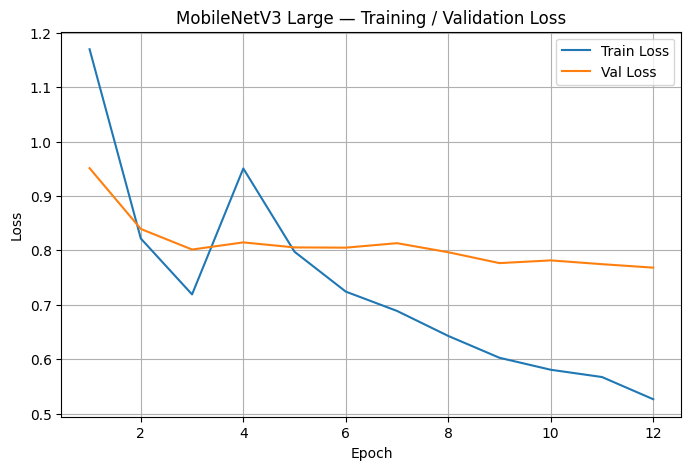

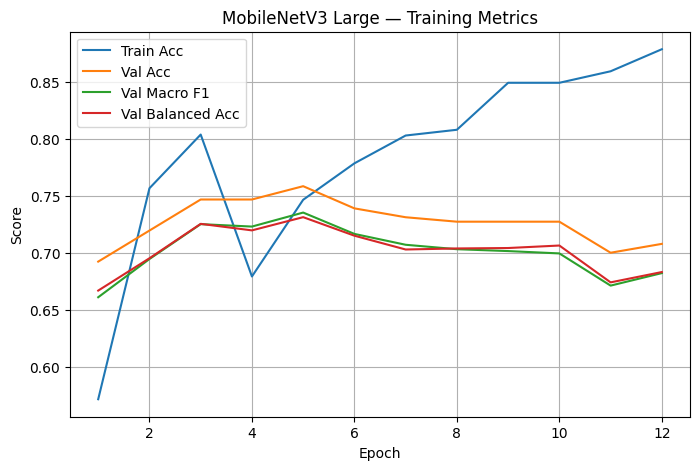

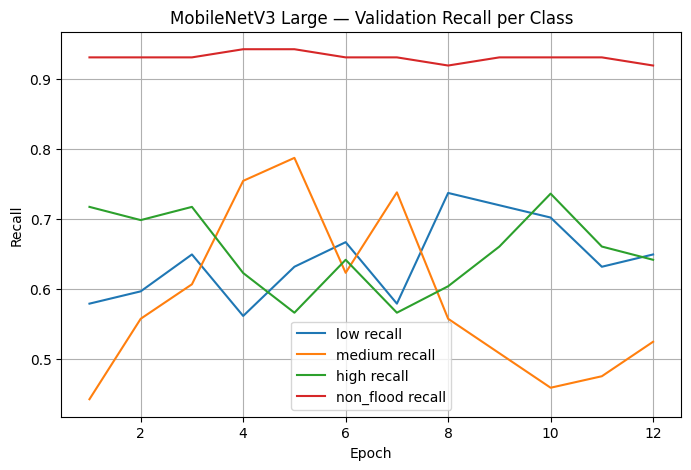

Saved figures:
/content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/loss_curve_mobilenetv3_large.png
/content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/metrics_curve_mobilenetv3_large.png
/content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/val_recall_per_class_mobilenetv3_large.png


In [17]:
history_df = pd.DataFrame(history)
display(history_df.tail())

def plot_history(history_df):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MobileNetV3 Large — Training / Validation Loss")
    plt.legend()
    plt.grid(True)
    loss_fig = os.path.join(OUTPUT_DIR, "loss_curve_mobilenetv3_large.png")
    plt.savefig(loss_fig, dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Acc")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
    plt.plot(history_df["epoch"], history_df["val_balanced_acc"], label="Val Balanced Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("MobileNetV3 Large — Training Metrics")
    plt.legend()
    plt.grid(True)
    metrics_fig = os.path.join(OUTPUT_DIR, "metrics_curve_mobilenetv3_large.png")
    plt.savefig(metrics_fig, dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    for cls in CLASS_ORDER:
        col = f"val_{cls}_recall"
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=f"{cls} recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("MobileNetV3 Large — Validation Recall per Class")
    plt.legend()
    plt.grid(True)
    recall_fig = os.path.join(OUTPUT_DIR, "val_recall_per_class_mobilenetv3_large.png")
    plt.savefig(recall_fig, dpi=160, bbox_inches="tight")
    plt.show()

    print("Saved figures:")
    print(loss_fig)
    print(metrics_fig)
    print(recall_fig)

plot_history(history_df)

## 12. Load best checkpoint và test evaluation

In [18]:
# Báo cáo cuối chỉ dùng test split độc lập; train/val tuyệt đối không được trộn vào.
train_groups_set = set(train_df["perceptual_group"])
val_groups_set = set(val_df["perceptual_group"])
test_groups_set = set(test_df["perceptual_group"])
assert train_groups_set.isdisjoint(val_groups_set)
assert train_groups_set.isdisjoint(test_groups_set)
assert val_groups_set.isdisjoint(test_groups_set)
print(f"Final evaluation split: test only ({len(test_df)} images)")

ckpt = torch.load(BEST_CKPT_PATH, map_location=device, weights_only=False)
print("Loaded checkpoint:", BEST_CKPT_PATH)
print("Checkpoint class_names:", ckpt["class_names"])
print("Checkpoint class_to_idx:", ckpt["class_to_idx"])
print("Best epoch:", ckpt["epoch"], "Best score:", ckpt["best_score"])
print("Best critical error rate:", ckpt.get("best_critical_error_rate"))
print("Selection reason:", ckpt.get("selection_reason"))

# Kiểm tra mapping để tránh lỗi lệch label.
assert ckpt["class_names"] == CLASS_ORDER, "Checkpoint class_names không khớp CLASS_ORDER hiện tại."

model = build_mobilenetv3_large(
    num_classes=len(ckpt["class_names"]),
    dropout=ckpt.get("dropout", DROPOUT),
    pretrained=False,
).to(device)
model.load_state_dict(ckpt["model_state_dict"])

# Validation dùng cho error analysis/relabel; tuyệt đối không dùng test để relabel.
val_review_metrics, review_true, review_pred, review_prob, review_paths = evaluate(
    model, val_loader, criterion, device
)

# Criterion cho test dùng lại weight/label_smoothing để loss nhất quán.
test_metrics, test_true, test_pred, test_prob, test_paths = evaluate(model, test_loader, criterion, device)

print("\nTEST METRICS")
for k in ["loss", "ce_loss", "severity_loss", "severity_penalty", "acc", "macro_f1", "balanced_acc", "critical_error_count", "critical_error_rate", "mean_severity_distance"]:
    print(f"{k}: {test_metrics[k]:.4f}")

print("\nTEST RECALL")
for cls in CLASS_ORDER:
    print(f"{cls}: {test_metrics[f'{cls}_recall']:.4f}")

report_text = classification_report(
    test_true,
    test_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
)
print("\nClassification report:")
print(report_text)

report_txt_path = os.path.join(OUTPUT_DIR, "classification_report_test_mobilenetv3_large.txt")
with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(report_text)

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_csv_path = os.path.join(OUTPUT_DIR, "classification_report_test_mobilenetv3_large.csv")
pd.DataFrame(report_dict).transpose().to_csv(report_csv_path)

test_metrics_path = os.path.join(OUTPUT_DIR, "test_metrics_mobilenetv3_large.json")
with open(test_metrics_path, "w", encoding="utf-8") as f:
    metrics_payload = {k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v
                       for k, v in test_metrics.items()}
    metrics_payload.update({"evaluation_split": "test", "num_samples": len(test_df), "model_version": MODEL_VERSION})
    json.dump(metrics_payload, f, ensure_ascii=False, indent=2)

comparison_path = os.path.join(OUTPUT_DIR, "experiment_comparison_mobilenetv3_large.csv")
best_val_metrics = ckpt["validation_metrics"]
comparison_row = {
    "evaluated_at": datetime.now().isoformat(timespec="seconds"),
    "severity_loss_weight": SEVERITY_LOSS_WEIGHT,
    "best_epoch": ckpt["epoch"],
    "val_accuracy": best_val_metrics["acc"],
    "val_macro_f1": best_val_metrics["macro_f1"],
    "val_critical_error_count": best_val_metrics["critical_error_count"],
    "val_critical_error_rate": best_val_metrics["critical_error_rate"],
    "val_mean_severity_distance": best_val_metrics["mean_severity_distance"],
}
comparison_df = pd.DataFrame([comparison_row])
if os.path.exists(comparison_path):
    comparison_df = pd.concat([pd.read_csv(comparison_path), comparison_df], ignore_index=True)
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", report_txt_path)
print("Saved:", report_csv_path)
print("Saved:", test_metrics_path)
print("Updated experiment comparison:", comparison_path)

Final evaluation split: test only (256 images)
Loaded checkpoint: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/flood_mobilenetv3_large_best.pth
Checkpoint class_names: ['low', 'medium', 'high', 'non_flood']
Checkpoint class_to_idx: {'low': 0, 'medium': 1, 'high': 2, 'non_flood': 3}
Best epoch: 5 Best score: 0.7587548638132295
Best critical error rate: 0.01556420233463035
Selection reason: higher_accuracy


Eval:   0%|          | 0/9 [00:00<?, ?it/s]

Eval:   0%|          | 0/8 [00:00<?, ?it/s]


TEST METRICS
loss: 0.7936
ce_loss: 0.7513
severity_loss: 0.4231
severity_penalty: 0.0423
acc: 0.7344
macro_f1: 0.7133
balanced_acc: 0.7093
critical_error_count: 4.0000
critical_error_rate: 0.0156
mean_severity_distance: 0.2812

TEST RECALL
low: 0.5000
medium: 0.7333
high: 0.6852
non_flood: 0.9186

Classification report:
              precision    recall  f1-score   support

         low     0.6512    0.5000    0.5657        56
      medium     0.5867    0.7333    0.6519        60
        high     0.8605    0.6852    0.7629        54
   non_flood     0.8316    0.9186    0.8729        86

    accuracy                         0.7344       256
   macro avg     0.7325    0.7093    0.7133       256
weighted avg     0.7408    0.7344    0.7307       256

Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/classification_report_test_mobilenetv3_large.txt
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/cla

## 13. Confusion matrix

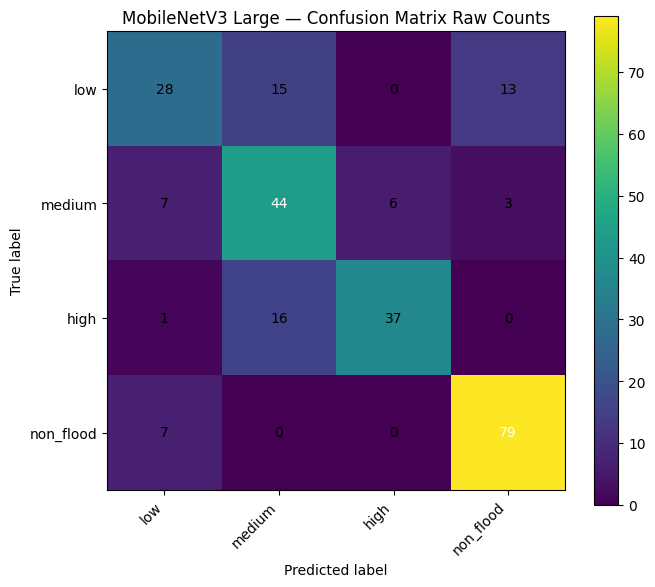

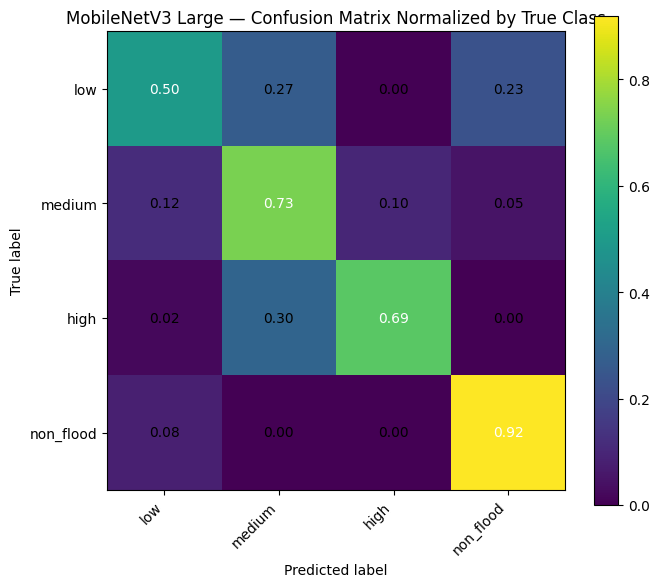

Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/cm_raw_test_mobilenetv3_large.png
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/cm_norm_test_mobilenetv3_large.png
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/cm_raw_test_mobilenetv3_large.csv
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/cm_norm_test_mobilenetv3_large.csv


In [19]:
def plot_confusion_matrix(cm, class_names, title, normalize=False, save_path=None):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0 if cm.size > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j,
                i,
                format(value, fmt),
                ha="center",
                va="center",
                color="white" if value > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


cm_raw = confusion_matrix(test_true, test_pred, labels=list(range(len(CLASS_ORDER))))
cm_norm = confusion_matrix(test_true, test_pred, labels=list(range(len(CLASS_ORDER))), normalize="true")

cm_raw_path = os.path.join(OUTPUT_DIR, "cm_raw_test_mobilenetv3_large.png")
cm_norm_path = os.path.join(OUTPUT_DIR, "cm_norm_test_mobilenetv3_large.png")
cm_raw_csv = os.path.join(OUTPUT_DIR, "cm_raw_test_mobilenetv3_large.csv")
cm_norm_csv = os.path.join(OUTPUT_DIR, "cm_norm_test_mobilenetv3_large.csv")

pd.DataFrame(cm_raw, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(cm_raw_csv)
pd.DataFrame(cm_norm, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(cm_norm_csv)

plot_confusion_matrix(
    cm_raw,
    CLASS_ORDER,
    "MobileNetV3 Large — Confusion Matrix Raw Counts",
    normalize=False,
    save_path=cm_raw_path,
)

plot_confusion_matrix(
    cm_norm,
    CLASS_ORDER,
    "MobileNetV3 Large — Confusion Matrix Normalized by True Class",
    normalize=True,
    save_path=cm_norm_path,
)

print("Saved:", cm_raw_path)
print("Saved:", cm_norm_path)
print("Saved:", cm_raw_csv)
print("Saved:", cm_norm_csv)

## 14. Xuất danh sách ảnh đoán sai để tiếp tục clean/relabel

In [20]:
def review_filename(relative_path):
    image_path = Path(relative_path)
    readable = re.sub(r'[<>:"/\\|?*\x00-\x1f]', '_', image_path.stem).strip(' .')[:24]
    digest = hashlib.sha256(relative_path.encode('utf-8')).hexdigest()[:10]
    return f"{readable or 'image'}_{digest}{image_path.suffix.lower()}"

mis_rows = []

for path, t, p, probs in zip(review_paths, review_true, review_pred, review_prob):
    if int(t) != int(p):
        row = {
            "path": path,
            "true_idx": int(t),
            "pred_idx": int(p),
            "true_label": CLASS_ORDER[int(t)],
            "pred_label": CLASS_ORDER[int(p)],
            "confidence": float(np.max(probs)),
            "true_prob": float(probs[int(t)]),
            "pred_prob": float(probs[int(p)]),
            "error_pair": f"{CLASS_ORDER[int(t)]}_to_{CLASS_ORDER[int(p)]}",
            "file_name": os.path.basename(path),
            "relative_path": Path(path).relative_to(DATA_DIR).as_posix(),
        }

        for i, cls in enumerate(CLASS_ORDER):
            row[f"prob_{cls}"] = float(probs[i])

        mis_rows.append(row)

mis_df = pd.DataFrame(mis_rows)
if len(mis_df) > 0:
    mis_df["review_file"] = mis_df["relative_path"].map(review_filename)
    assert mis_df["review_file"].is_unique, "Tên ảnh review bị trùng."
    mis_df["severity_distance"] = (
        mis_df["true_label"].map(SEVERITY_RANK)
        - mis_df["pred_label"].map(SEVERITY_RANK)
    ).abs().astype(int)

mis_path = os.path.join(OUTPUT_DIR, "misclassified_val_mobilenetv3_large.csv")
save_nonempty_csv(mis_df, mis_path, index=False)

# Lỗi nghiêm trọng là dự đoán lệch từ hai mức trở lên:
# low <-> high, non_flood <-> medium và non_flood <-> high.
critical_df = pd.DataFrame()
if len(mis_df) > 0:
    critical_df = (
        mis_df[mis_df["severity_distance"] >= CRITICAL_DISTANCE]
        .sort_values(["severity_distance", "confidence"], ascending=[False, False])
        .reset_index(drop=True)
    )
critical_path = os.path.join(OUTPUT_DIR, "critical_severity_errors_val_mobilenetv3_large.csv")
save_nonempty_csv(critical_df, critical_path, index=False)

print("Misclassified count:", len(mis_df))
print("Critical severity error count:", len(critical_df))

if len(mis_df) > 0:
    display(mis_df.sort_values(["error_pair", "confidence"], ascending=[True, False]).head(30))

# Tổng hợp toàn bộ lỗi theo cặp.
pair_summary_path = os.path.join(OUTPUT_DIR, "misclassified_pair_summary_mobilenetv3_large.csv")
pair_summary = pd.DataFrame(columns=["true_label", "pred_label", "count"])
if len(mis_df) > 0:
    pair_summary = (
        mis_df.groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(pair_summary)
save_nonempty_csv(pair_summary, pair_summary_path, index=False)

Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/misclassified_val_mobilenetv3_large.csv
Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/critical_severity_errors_val_mobilenetv3_large.csv
Misclassified count: 62
Critical severity error count: 4


,path,true_idx,pred_idx,true_label,pred_label,confidence,true_prob,pred_prob,error_pair,file_name,relative_path,prob_low,prob_medium,prob_high,prob_non_flood,review_file,severity_distance
35,/content/flood_dataset_v4/Dataset_Flood/high/d...,2,0,high,low,0.328125,0.131714,0.328125,high_to_low,download.webp,high/download.webp,0.328125,0.227905,0.131714,0.312256,download_a09bc33dd9.webp,2
46,/content/flood_dataset_v4/Dataset_Flood/high/i...,2,1,high,medium,0.848633,0.146606,0.848633,high_to_medium,img55.webp,high/img55.webp,0.004375,0.848633,0.146606,0.000283,img55_ef7e3ec4b2.webp,1
54,/content/flood_dataset_v4/Dataset_Flood/high/O...,2,1,high,medium,0.786621,0.096497,0.786621,high_to_medium,OIP (29).webp,high/OIP (29).webp,0.115662,0.786621,0.096497,0.001503,OIP (29)_d55ffe2bba.webp,1
47,/content/flood_dataset_v4/Dataset_Flood/high/i...,2,1,high,medium,0.756348,0.229126,0.756348,high_to_medium,image_6483441_7_c62ccb313f.jpg,high/image_6483441_7_c62ccb313f.jpg,0.014107,0.756348,0.229126,0.000419,image_6483441_7_c62ccb31_dfb6d0bdf2.jpg,1
34,/content/flood_dataset_v4/Dataset_Flood/high/f...,2,1,high,medium,0.710449,0.209595,0.710449,high_to_medium,floods_cambodia_avid_w.jpg,high/floods_cambodia_avid_w.jpg,0.077393,0.710449,0.209595,0.002499,floods_cambodia_avid_w_bfdf09db61.jpg,1
39,/content/flood_dataset_v4/Dataset_Flood/high/i...,2,1,high,medium,0.707520,0.227661,0.707520,high_to_medium,images - 2025-01-28T151851.902.jpg,high/images - 2025-01-28T151851.902.jpg,0.059296,0.707520,0.227661,0.005684,images - 2025-01-28T1518_571260e8dc.jpg,1
36,/content/flood_dataset_v4/Dataset_Flood/high/f...,2,1,high,medium,0.672363,0.261475,0.672363,high_to_medium,flood_4800.jpg,high/flood_4800.jpg,0.063721,0.672363,0.261475,0.002741,flood_4800_f64a5b284b.jpg,1
49,/content/flood_dataset_v4/Dataset_Flood/high/O...,2,1,high,medium,0.668945,0.138672,0.668945,high_to_medium,OIP (33).webp,high/OIP (33).webp,0.190918,0.668945,0.138672,0.001680,OIP (33)_1c18f33b5d.webp,1
53,/content/flood_dataset_v4/Dataset_Flood/high/i...,2,1,high,medium,0.668457,0.189453,0.668457,high_to_medium,images - 2025-01-28T152121.677.jpg,high/images - 2025-01-28T152121.677.jpg,0.103210,0.668457,0.189453,0.038818,images - 2025-01-28T1521_ccca6dd108.jpg,1
56,/content/flood_dataset_v4/Dataset_Flood/high/O...,2,1,high,medium,0.649414,0.251465,0.649414,high_to_medium,OIP (36).webp,high/OIP (36).webp,0.095947,0.649414,0.251465,0.003151,OIP (36)_d0aa4dbccd.webp,1


,true_label,pred_label,count
1,high,medium,21
4,low,medium,12
6,medium,high,8
5,low,non_flood,8
9,non_flood,low,5
7,medium,low,4
0,high,low,1
3,low,high,1
2,high,non_flood,1
8,medium,non_flood,1


Saved: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/misclassified_pair_summary_mobilenetv3_large.csv


True

In [21]:
def copy_misclassified_by_pair(mis_df, output_dir, max_per_pair=None):
    review_dir = os.path.join(output_dir, "review_misclassified_by_pair_mobilenetv3_large")
    if len(mis_df) == 0:
        remove_artifact_if_exists(review_dir)
        print("No misclassified images; review folder was not created.")
        return None

    if os.path.exists(review_dir):
        shutil.rmtree(review_dir)
    os.makedirs(review_dir, exist_ok=True)

    copied = 0
    copied_rows = []
    for pair, group in mis_df.groupby("error_pair"):
        pair_dir = os.path.join(review_dir, pair)
        os.makedirs(pair_dir, exist_ok=True)
        pair_copied = 0

        group = group.sort_values("confidence", ascending=False)
        if max_per_pair is not None:
            group = group.head(max_per_pair)

        for _, row in group.iterrows():
            src = row["path"]
            dst_name = row["review_file"]
            dst = os.path.join(pair_dir, dst_name)
            shutil.copy2(src, dst)
            copied += 1
            copied_rows.append(row)
            pair_copied += 1

        if pair_copied == 0:
            remove_artifact_if_exists(pair_dir)

    if copied == 0:
        remove_artifact_if_exists(review_dir)
        print("No review images were copied; review folder was removed.")
        return None

    pd.DataFrame(copied_rows)[["error_pair", "review_file", "relative_path", "true_label", "pred_label", "confidence"]].to_csv(
        os.path.join(review_dir, "index.csv"), index=False, encoding="utf-8-sig"
    )
    print(f"Copied {copied} misclassified images to:", review_dir)
    return review_dir


review_dir = copy_misclassified_by_pair(mis_df, OUTPUT_DIR, max_per_pair=None)

Copied 62 misclassified images to: /content/drive/MyDrive/Colab Notebooks/NCKH/models/mobilenetv3_large_dataset_v4_seed599/review_misclassified_by_pair_mobilenetv3_large


In [22]:
def show_misclassified(mis_df, n=12, sort_by="confidence"):
    fig_path = os.path.join(OUTPUT_DIR, "misclassified_examples_mobilenetv3_large.png")
    if len(mis_df) == 0:
        remove_artifact_if_exists(fig_path)
        print("No misclassified images; example figure was not created.")
        return

    if sort_by and sort_by in mis_df.columns:
        sample = mis_df.sort_values(sort_by, ascending=False).head(min(n, len(mis_df)))
    else:
        sample = mis_df.sample(min(n, len(mis_df)), random_state=SEED)

    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"T: {row['true_label']} | P: {row['pred_label']}\n"
            f"conf={row['confidence']:.2f}, true_prob={row['true_prob']:.2f}"
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


show_misclassified(mis_df, n=12, sort_by="confidence")

Output hidden; open in https://colab.research.google.com to view.

## 15. Inference test cho 1 ảnh

In [23]:
@torch.no_grad()
def predict_image(image_path, checkpoint_path=BEST_CKPT_PATH, top_k=4):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    class_names = ckpt["class_names"]
    image_size = ckpt.get("image_size", IMAGE_SIZE)
    letterbox_fill = ckpt.get("letterbox_fill", LETTERBOX_FILL)
    mean = ckpt.get("imagenet_mean", IMAGENET_MEAN)
    std = ckpt.get("imagenet_std", IMAGENET_STD)

    model = build_mobilenetv3_large(
        num_classes=len(class_names),
        dropout=ckpt.get("dropout", DROPOUT),
        pretrained=False,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    transform = transforms.Compose([
        Letterbox(image_size, letterbox_fill),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    with Image.open(image_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    order = np.argsort(probs)[::-1][:top_k]
    result = [(class_names[i], float(probs[i])) for i in order]

    pred_label = result[0][0]
    confidence = result[0][1]

    return {
        "image_path": image_path,
        "pred_label": pred_label,
        "confidence": confidence,
        "top_k": result,
    }


# Ví dụ:
# sample_path = test_df.iloc[0]["path"]
# predict_image(sample_path)

## Ghi chú dùng sau khi train MobileNetV3 Large

Mỗi seed ghi output riêng vào `models/mobilenetv3_large_dataset_v4_seed{SEED}`.
Split manifest dùng chung nằm tại `models/mobilenetv3_large_dataset_v4/split_train_val_test_mobilenetv3_large.csv`.

Trong thư mục output của từng seed, xem:
- `perceptual_near_duplicates_mobilenetv3_large.csv`: audit ảnh gần giống cùng group.
- `perceptual_conflicts_cross_label_mobilenetv3_large.csv`: ảnh gần giống nhưng khác nhãn đã bị loại để review.
- `history_mobilenetv3_large.csv`: log từng epoch.
- `classification_report_test_mobilenetv3_large.txt`: xem `macro_f1`, `balanced_acc`, recall từng class.
- `experiment_comparison_mobilenetv3_large.csv`: lưu nối tiếp validation accuracy và critical error rate của baseline `λ=0.0` và các lần thử severity-aware; không dùng test để chọn λ.
- `cm_raw_test_mobilenetv3_large.png` và `cm_norm_test_mobilenetv3_large.png`: xem class nào còn nhầm nhiều.
- `misclassified_val_mobilenetv3_large.csv`: danh sách ảnh validation đoán sai để relabel; không dùng test cho vòng lặp phát triển.
- `critical_severity_errors_val_mobilenetv3_large.csv`: chỉ gồm lỗi lệch từ hai mức trở lên (`low↔high`, `non_flood↔medium/high`).
- `review_misclassified_by_pair_mobilenetv3_large/`: ảnh đoán sai theo từng cặp lỗi; `index.csv` trong thư mục này nối tên ảnh review với `relative_path` trong dataset.

Ưu tiên kiểm tra các cặp lỗi:

1. `low ↔ non_flood`: thường do ảnh chỉ mưa/đường ướt/vũng nhỏ nhưng bị gán low.
2. `low ↔ medium`: thường do thiếu mốc đầu gối/bánh xe/yên xe.
3. `medium ↔ high`: thường do model học cảm giác thảm họa thay vì độ sâu nước.

Mốc đánh giá nên hướng tới trước khi xem là ổn:

- `non_flood recall >= 0.90`
- `low recall >= 0.80`
- `medium recall >= 0.75`
- `high recall >= 0.75`
- `macro_f1 >= 0.80`
- `balanced_acc >= 0.80`

Nếu `train_acc` rất cao nhưng `val_macro_f1` thấp, đừng tăng epoch. Hãy:
- clean lại nhãn ambiguous,
- bổ sung ảnh `high` có mốc rõ,
- bổ sung hard negative `non_flood` như mưa, đường ướt, vũng nước nhỏ,
- tránh augmentation/crop quá mạnh làm mất vật tham chiếu.